## Run the shapefile on a gerrychain.

In [1]:
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from gerrychain.metrics import efficiency_gap

import geopandas as gpd

In [2]:
RI_graph = Graph.from_file("./FinalShapeFiles/RI.shp")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gerrychain/graph/graph.py:406: UserWarning: Found islands (degree-0 nodes). Indices of islands: {91}
  warnings.warn(


In [3]:
# Check if the dual graph is connected
import networkx as nx
is_contig = nx.is_connected(RI_graph)
print(f"Dual graph is connected or not: {is_contig}")

Dual graph is connected or not: False


Make the dual graph connected by connecting the isolated Island.

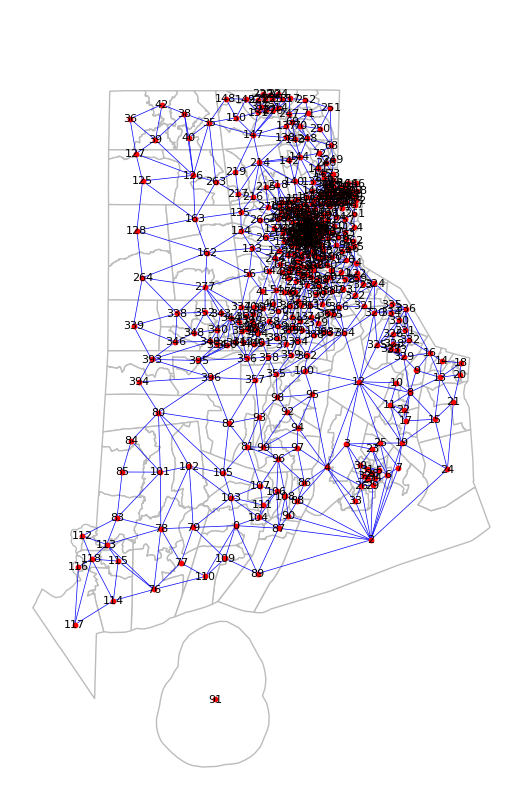

In [4]:
# CITE: https://networkx.org/documentation/stable/tutorial.html
import geopandas as gpd
import matplotlib.pyplot as plt
from gerrychain import Graph

RI_df = gpd.read_file("./FinalShapeFiles/RI.shp")

fig, ax = plt.subplots(figsize=(10, 10))

RI_df.plot(ax=ax, color="white", edgecolor="#bcbcbc")

# get the centriod of each place
pos = {node: (RI_df.geometry[node].centroid.x, RI_df.geometry[node].centroid.y) for node in RI_graph.nodes}

import networkx as nx
nx.draw(RI_graph, 
        pos, 
        ax=ax, 
        node_size=10, 
        node_color="red", 
        edge_color="blue", 
        labels={node: node for node in RI_graph.nodes},
        font_size=8,         
        width=0.5
)

plt.title("Dual Graph of Rhode Island")
plt.show()

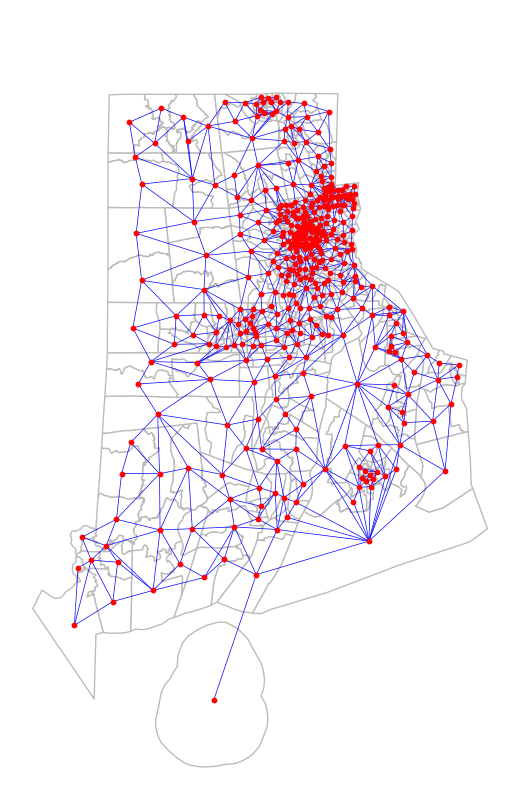

In [5]:
# As there's population, Look for rules for districting
# if there's population, add small number of edges.

# Connect node 89 and 110 with node 91
RI_graph.add_edge(89, 91)
           
# draw the graph again to verify
fig, ax = plt.subplots(figsize=(10, 10))

RI_df.plot(ax=ax, color="white", edgecolor="#bcbcbc")

# get the centriod of each place
pos = {node: (RI_df.geometry[node].centroid.x, RI_df.geometry[node].centroid.y) for node in RI_graph.nodes}

nx.draw(RI_graph, 
        pos, 
        ax=ax, 
        node_size=10, 
        node_color="red", 
        edge_color="blue", 
        width=0.5
)

plt.title("Modified Dual Graph of Rhode Island")
plt.show()

In [6]:
import networkx as nx
is_contig = nx.is_connected(RI_graph)
print(f"Dual graph is connected or not: {is_contig}")

Dual graph is connected or not: True


### Creating at least 2 Markov Chain ensembles using ReCom 
1. Use 2020 Presidential Election (G20PREDBID (Democrat), G20PRERTRU(Republican))
2. Use 2020 U.S. Senate Election (G20USSDREE (Democrat), G20USSRWAT(Republican))

In [7]:
from functools import partial
from gerrychain.proposals import recom

ri_data = gpd.read_file("./FinalShapeFiles/RI.shp")
district_summary = ri_data.groupby("SEND")["TOTPOP"].sum()

total_population = district_summary.sum()
number_of_districts = len(district_summary)

ideal_pop = total_population / number_of_districts

pop_tolerance = 0.1
rw_proposal = partial(recom, ## how you choose a next districting plan
                      pop_col = "TOTPOP", ## What data describes population
                      pop_target = ideal_pop, ## What the target/ideal population is for each district 
                                              ## (we calculated ideal pop above)
                      epsilon = pop_tolerance,  ## how far from ideal population you can deviate
                                              ## (we set pop_tolerance above)
                      node_repeats = 1 ## number of times to repeat bipartition.  Can increase if you get a BipartitionWarning
                      )

In [8]:
# 1. 2020 Presidential Election
pres_election = Election(
    "Pres20",
    {"Dem": "PRES20D", "Rep": "PRES20R"}
)

# 2. 2020 U.S. Senate Election
senate_election = Election(
    "Sen20",
    {"Dem": "SEN20D", "Rep": "SEN20R"}
)

my_updaters = {
    "population": Tally("TOTPOP", alias="population"), 
    "cut_edges": cut_edges,
    "VAP": Tally("VAP", alias="VAP"),
    "HVAP": Tally("HVAP", alias="HVAP"),
    # "BVAP": Tally("BVAP", alias="BVAP"),
    "Pres20": pres_election,
    "Sen20": senate_election,

    # Get the efficiency gap
    "eff_gap_pres": lambda p: efficiency_gap(p["Pres20"]),
    "eff_gap_sen": lambda p: efficiency_gap(p["Sen20"])
}

initial_partition = Partition(
    RI_graph,              
    assignment="SEND",      
    updaters=my_updaters
)

In [9]:
population_constraint = constraints.within_percent_of_ideal_population(
    initial_partition, 
    pop_tolerance
)

our_random_walk = MarkovChain(
    proposal = rw_proposal, 
    constraints = [population_constraint], # Could add additional constraints here
    accept = always_accept, # Accept every proposed plan that meets the population constraints
    initial_state = initial_partition, 
    total_steps = 50)  

In [10]:
pres_dem_seats = []
sen_dem_seats = []
cutedge_ensemble = []
pres_eg_scores = []
sen_eg_scores = []
latino_districts_ensemble = []

dist_ids = list(initial_partition.parts.keys())

for part in our_random_walk:
    cutedge_ensemble.append(len(part["cut_edges"]))
    
    num_lat_majority = 0

    # store number of seats that demo wins in 2 elections
    pres_dem_seats.append(part["Pres20"].wins("Dem"))
    sen_dem_seats.append(part["Sen20"].wins("Dem"))

    cutedge_ensemble.append(len(part["cut_edges"]))
    
    # store efficiency gap in 2 elections
    pres_eg_scores.append(part["eff_gap_pres"])
    sen_eg_scores.append(part["eff_gap_sen"])

    num_lat_majority = sum(1 for pct in part["HVAP"].values() if pct >= 0.5)
    latino_districts_ensemble.append(num_lat_majority)
    
   

For each ensemble: outlier analysis/histogram for:
- Efficiency Gap
- Dem-won (or Rep-won) districts
- Cut edges or Polsby-Popper score

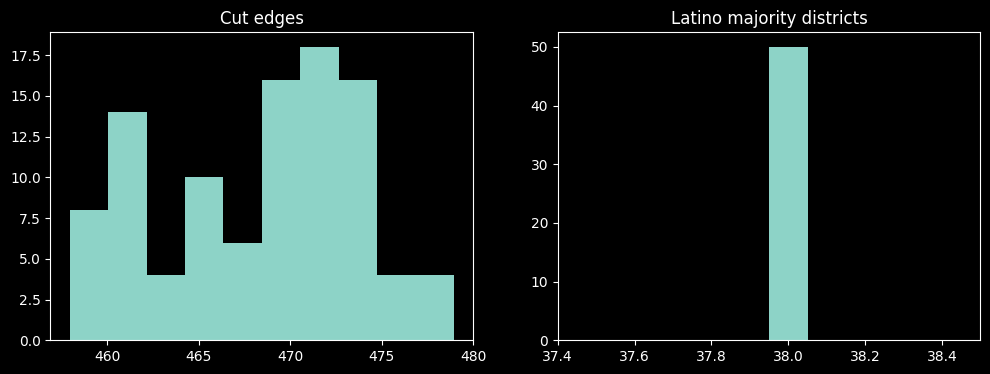

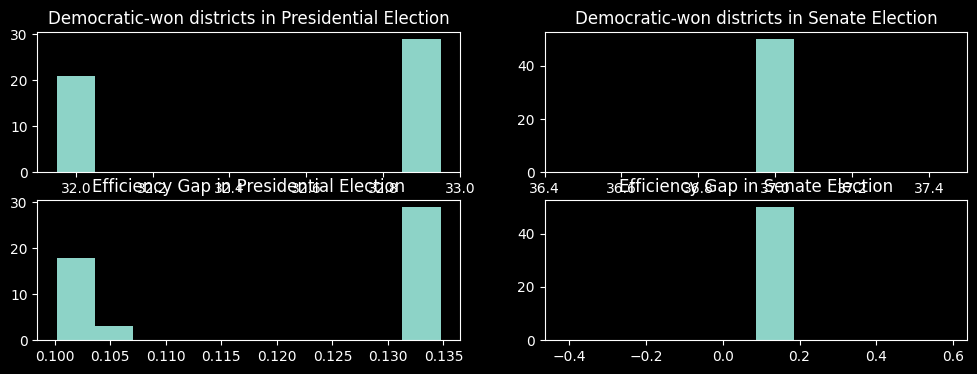

<Figure size 640x480 with 0 Axes>

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cutedge_ensemble, align = 'left')
axes[0].set_title("Cut edges")

axes[1].hist(latino_districts_ensemble, align = 'left')
axes[1].set_title("Latino majority districts")

fig, axes = plt.subplots(2, 2, figsize=(12, 4))

plt.figure()

axes[0][0].hist(pres_dem_seats, align = 'left')
axes[0][0].set_title("Democratic-won districts in Presidential Election")

axes[0][1].hist(sen_dem_seats, align = 'left')
axes[0][1].set_title("Democratic-won districts in Senate Election")

axes[1][0].hist(pres_eg_scores, align = 'left')
axes[1][0].set_title("Efficiency Gap in Presidential Election")

axes[1][1].hist(sen_eg_scores, align = 'left')
axes[1][1].set_title("Efficiency Gap in Senate Election")

plt.show()

TODO: Evidence of convergence (that you have run the chain long enough)

In [12]:
pres_dem_seats = []
sen_dem_seats = []
cutedge_ensemble = []
pres_eg_scores = []
sen_eg_scores = []
latino_districts_ensemble = []


our_random_walk = MarkovChain(
    proposal = rw_proposal, 
    constraints = [population_constraint], # Could add additional constraints here
    accept = always_accept, # Accept every proposed plan that meets the population constraints
    initial_state = initial_partition, 
    total_steps = 40000)  

cutedge_ensemble = []
latino_districts_ensemble = []
dem_wins_ensemble = []

for part in our_random_walk:
    cutedge_ensemble.append(len(part["cut_edges"]))
    
    num_lat_majority = 0

    # store number of seats that demo wins in 2 elections
    pres_dem_seats.append(part["Pres20"].wins("Dem"))
    sen_dem_seats.append(part["Sen20"].wins("Dem"))

    cutedge_ensemble.append(len(part["cut_edges"]))
    
    # store efficiency gap in 2 elections
    pres_eg_scores.append(part["eff_gap_pres"])
    sen_eg_scores.append(part["eff_gap_sen"])

    num_lat_majority = sum(1 for pct in part["HVAP"].values() if pct >= 0.5)
    latino_districts_ensemble.append(num_lat_majority)

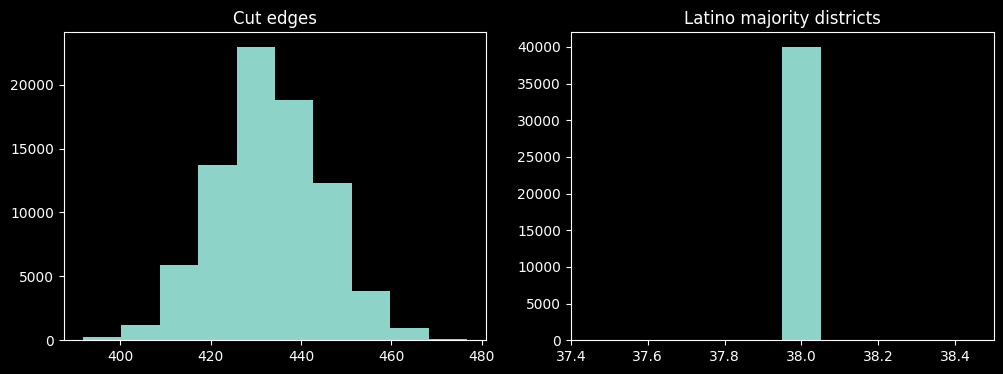

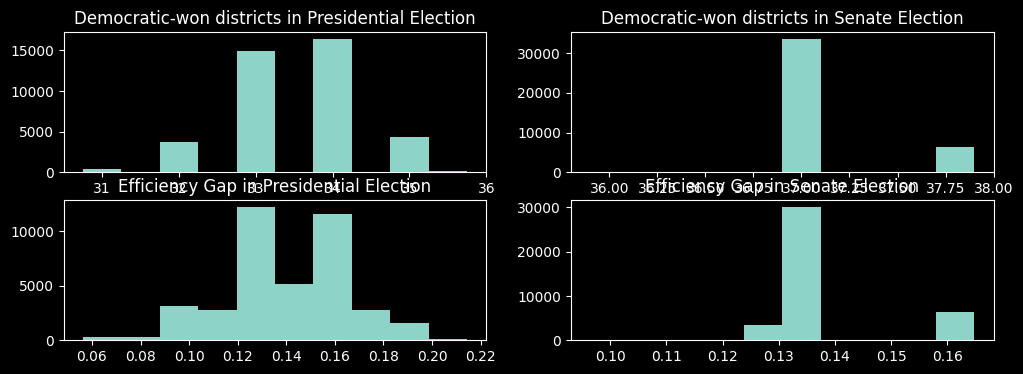

<Figure size 640x480 with 0 Axes>

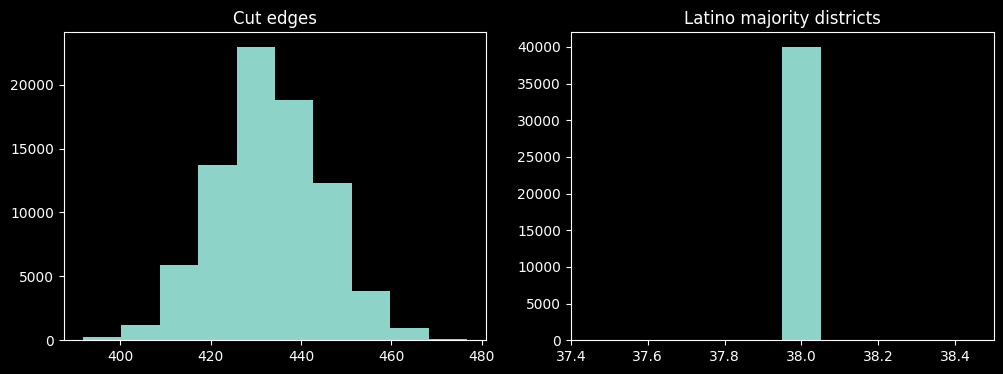

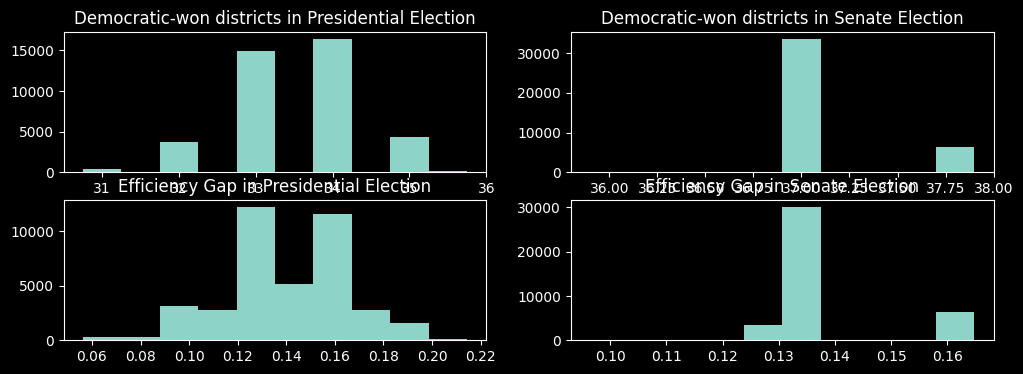

<Figure size 640x480 with 0 Axes>

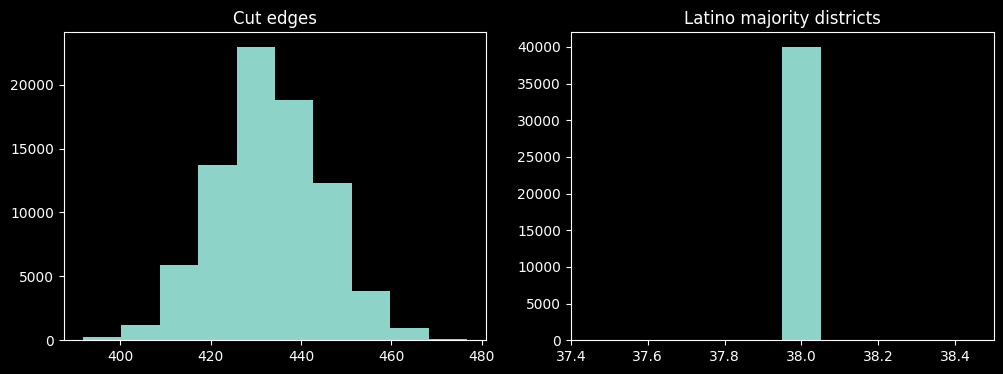

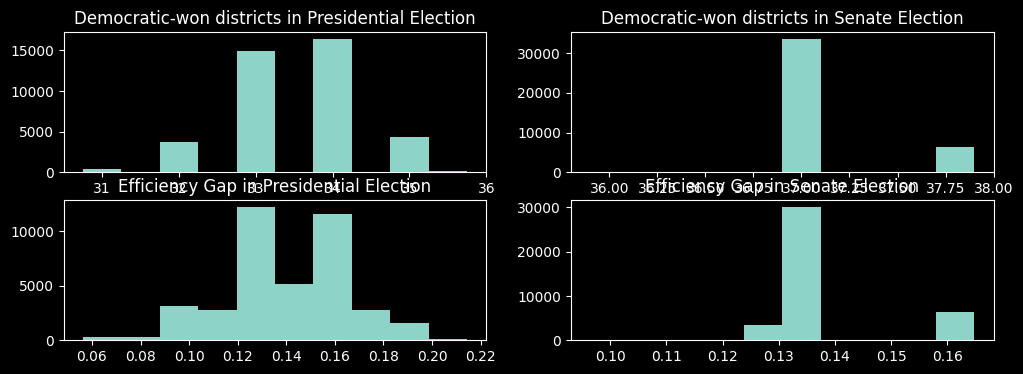

<Figure size 640x480 with 0 Axes>

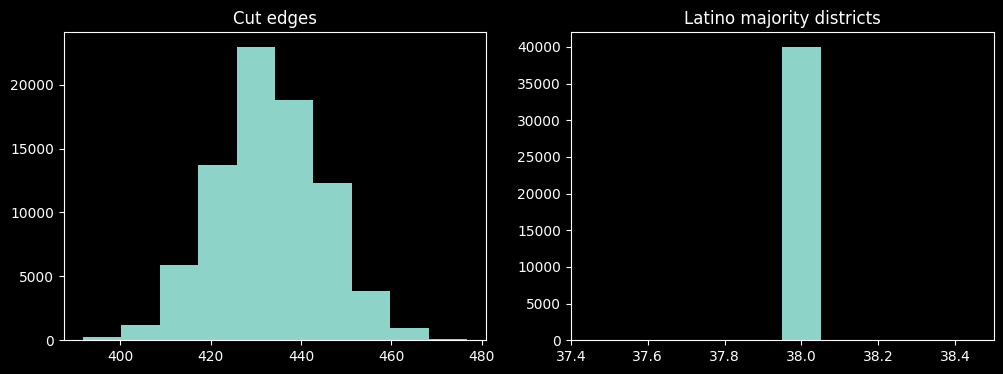

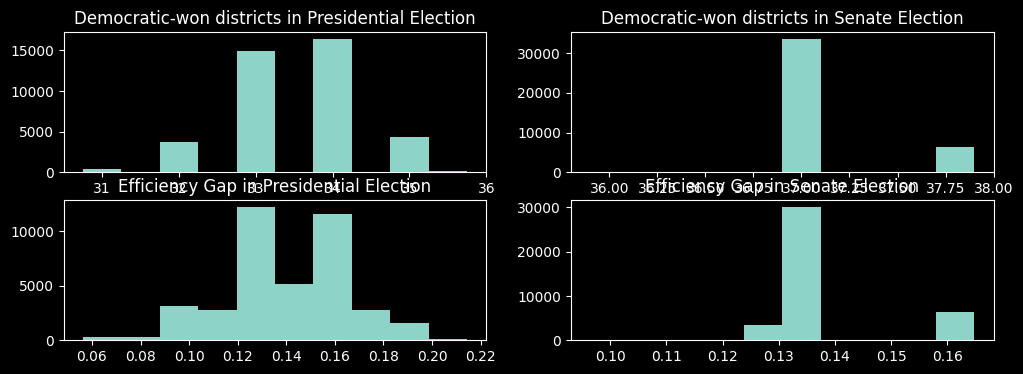

<Figure size 640x480 with 0 Axes>

In [13]:
for size in [1000, 10000, 20000, 40000]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(cutedge_ensemble, align = 'left')
    axes[0].set_title("Cut edges")
    
    axes[1].hist(latino_districts_ensemble, align = 'left')
    axes[1].set_title("Latino majority districts")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 4))
    
    plt.figure()
    
    axes[0][0].hist(pres_dem_seats, align = 'left')
    axes[0][0].set_title("Democratic-won districts in Presidential Election")
    
    axes[0][1].hist(sen_dem_seats, align = 'left')
    axes[0][1].set_title("Democratic-won districts in Senate Election")
    
    axes[1][0].hist(pres_eg_scores, align = 'left')
    axes[1][0].set_title("Efficiency Gap in Presidential Election")
    
    axes[1][1].hist(sen_eg_scores, align = 'left')
    axes[1][1].set_title("Efficiency Gap in Senate Election")
    
    plt.show()

Marginal box plots (sometimes called the “signature of gerrymandering”)